# Matplotlib study

[Matplotlib doc](https://matplotlib.org/stable/index.html)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import librosa
import librosa.display
from sklearn.preprocessing import minmax_scale

sys.path.insert(0, os.path.abspath('..'))
from dataprocess.cwt.cwt2 import cwt2, rd_file, cwt3
from dataprocess.util.data_process import replace_zeroes

from IPython.display import Audio

DATA_DIR = '../data/sound/grasshopper-sound-4/'
CMAP = 'magma'

In [5]:
fn = f'{DATA_DIR}gh-4_mono_22050_denoised_filter.wav'
d1, sr1, dura1 = rd_file(fn)
Audio(d1, rate=sr1)

In [6]:
F_MAX = sr1 // 2
S = librosa.feature.melspectrogram(y=d1, sr=sr1, n_mels=256, fmax=F_MAX)
S_db = librosa.power_to_db(S, ref=np.max)

d2, sr2 = librosa.load(fn)
d2 = minmax_scale(d2 - d2.mean(), feature_range=(-1,1))
cs1, f1 = cwt2(d2, nv=12, sr=sr2, low_freq=40)
#cs1, f1 = cwt3(d2, nv=12, sr=sr2, low_freq=40)
print(f'shape of cs1: {cs1.shape}')
print(f'cs1:\n{cs1[10][52000:52020]}')
print(f'shape of f1: {f1.shape}')

shape of cs1: (97, 228217)
cs1:
[ 7.12491486e-05-1.95990946e-05j  7.87312505e-06+7.07842950e-05j
 -6.41705055e-05-2.34476687e-06j  1.03763241e-05-5.22787008e-05j
  3.71849155e-05+1.55485586e-05j -1.71843051e-05+2.17836360e-05j
 -9.06818027e-06-1.50732310e-05j  1.00470810e-05-1.16415041e-06j
 -1.52620192e-06+4.11026923e-06j  1.66328710e-07-6.00666350e-07j
 -9.11857712e-07+7.78213199e-07j  2.65895912e-06+1.98132938e-07j
 -5.94768444e-06+8.55908365e-06j -1.39714564e-05-1.63250659e-05j
  2.93824609e-05-1.58650359e-05j  1.24396555e-05+4.21701843e-05j
 -5.20043039e-05+3.80457630e-06j  8.28092098e-06-5.74223648e-05j
  5.83912806e-05+2.13951601e-05j -3.35759217e-05+5.57682195e-05j]
shape of f1: (97,)


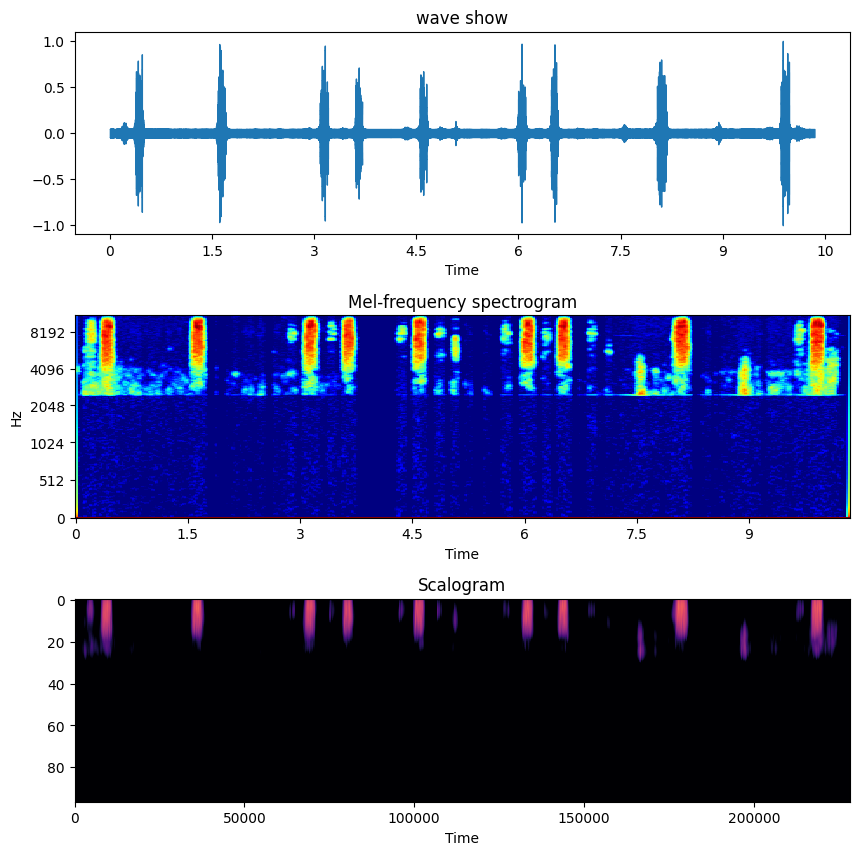

In [7]:
#fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=False)

librosa.display.waveshow(y=d1, sr=sr1, ax=axes[0])
axes[0].set(title='wave show')

img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr1, fmax=F_MAX, cmap='jet', ax=axes[1])
# fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set(title='Mel-frequency spectrogram')

cs1 = replace_zeroes(cs1)
axes[2].imshow(20*np.log10(np.abs(cs1)), cmap=CMAP, aspect='auto', norm=None, 
    vmax=0, vmin=-60,
    #extent=[0.0, dura1, cs1.shape[0], 0]
)
axes[2].set_xlabel('Time')
axes[2].set(title='Scalogram')

fig.subplots_adjust(hspace=0.4)
plt.show()


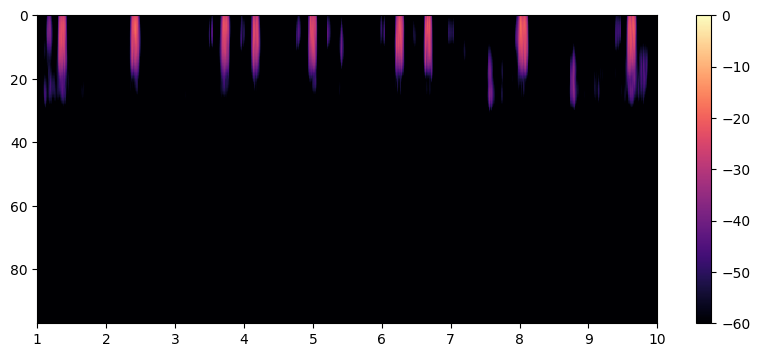

In [9]:
fig, ax = plt.subplots(figsize = (10,4))
img = ax.imshow(20*np.log10(np.abs(cs1)), cmap='magma', aspect='auto', norm=None, vmax=0, vmin=-60, extent=[1.0, 10.0, cs1.shape[0], 0])
fig.colorbar(img, ax=ax)